# CIFAR-10-C: OOD Conformal Prediction + Drift Detection

This notebook merges two ideas into one end-to-end protocol:

1. **Split-conformal under covariate shift**: train and calibrate on clean CIFAR-10, then evaluate coverage on CIFAR-10-C across corruption type and severity.
2. **Online drift detection**: monitor a stream that switches from clean to corrupted data using CUSUM, MMD, and KS tests.

## Protocol

1. Train a lightweight CNN on clean CIFAR-10 train split.
2. Calibrate split-conformal threshold (`q_hat`) on a clean calibration split.
3. Evaluate coverage on clean hold-out and full CIFAR-10-C corruption x severity grid.
4. Calibrate drift detectors on clean data.
5. Run a clean -> corrupted stream and log detector alerts.

In [1]:
import math
import os
from river import tree, drift

import matplotlib
# Keep notebook plots interactive; force Agg only for explicit headless runs.
if os.environ.get('HEADLESS', '0') == '1':
    matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np
import torch
import torchvision
import torchvision.transforms as T
from scipy.stats import ks_2samp
from scipy.spatial.distance import jensenshannon
from torch import nn
from torch.utils.data import DataLoader, TensorDataset, random_split

In [2]:
# Core settings
ALPHA = 0.10
EPOCHS = 10
BATCH_SIZE = 128
SEED = 42

# Drift settings
STREAM_CLEAN_BATCHES = 20
STREAM_NOISY_BATCHES = 20
STREAM_WINDOW = 5
MMD_PERMUTATIONS = 300
NULL_SAMPLES = 200

# Chosen corruption for stream and per-class diagnostics
TARGET_CORRUPTION = 'gaussian_noise'
TARGET_SEVERITY = 3

# CIFAR-10-C path fallback chain
DATA_C_DIR = '/data/CIFAR-10-C'
if not os.path.exists(DATA_C_DIR):
    candidate = './data/CIFAR-10-C'
    DATA_C_DIR = candidate if os.path.exists(candidate) else './playground/data/CIFAR-10-C'

# Save outputs to ./playground when running from repo root, otherwise current directory.
OUTPUT_DIR = './playground' if os.path.isdir('./playground') else '.'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Model checkpoint settings
FORCE_RETRAIN = False
MODEL_CKPT_PATH = os.path.join(OUTPUT_DIR, f'simplecnn_cifar10_seed{SEED}_ep{EPOCHS}.pt')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device       :', device)
print('CIFAR-10-C   :', DATA_C_DIR)

CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck']

CORRUPTIONS = sorted([
    f[:-4] for f in os.listdir(DATA_C_DIR) if f.endswith('.npy') and f != 'labels.npy'
])
print(f'Corruptions  : {len(CORRUPTIONS)} types')

Device       : cpu
CIFAR-10-C   : ./data/CIFAR-10-C
Corruptions  : 1 types


## 1) Data: clean train + clean cal/test splits

In [3]:
torch.manual_seed(SEED)
np.random.seed(SEED)

mean = (0.4914, 0.4822, 0.4465)
std = (0.2470, 0.2435, 0.2616)

train_transform = T.Compose([
    T.RandomCrop(32, padding=4),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize(mean, std),
])
test_transform = T.Compose([
    T.ToTensor(),
    T.Normalize(mean, std),
])

clean_train_ds = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=train_transform
)
clean_test_ds = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=test_transform
)

# Split clean test set into calibration and hold-out test
generator = torch.Generator().manual_seed(SEED)
n_test = len(clean_test_ds)
cal_size = n_test // 2
test_size = n_test - cal_size
clean_cal_ds, clean_test_hold_ds = random_split(
    clean_test_ds, [cal_size, test_size], generator=generator
)

train_loader = DataLoader(clean_train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
cal_loader_clean = DataLoader(clean_cal_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader_clean = DataLoader(clean_test_hold_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'Train : {len(clean_train_ds):,}')
print(f'Cal   : {len(clean_cal_ds):,}')
print(f'Test  : {len(clean_test_hold_ds):,}')

c:\Users\anna.gavrilova.TENZORTECH\uni\machine_learning\drift_conf_active_learning\new\dacal-stream-learning\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Train : 50,000
Cal   : 5,000
Test  : 5,000


## 2) Model and training helpers

In [4]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.AdaptiveAvgPool2d(4),
        )
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.relu = nn.ReLU()
        self.drop = nn.Dropout(0.4)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        h = self.features(x)
        h = self.flatten(h)
        h = self.fc1(h)
        h = self.relu(h)
        h = self.drop(h)
        return self.fc2(h)

    def get_embeddings(self, x):
        # Embeddings before final classification layer.
        h = self.features(x)
        h = self.flatten(h)
        h = self.fc1(h)
        h = self.relu(h)
        return h


def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct = 0.0, 0
    for X_b, y_b in loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        optimizer.zero_grad()
        logits = model(X_b)
        loss = criterion(logits, y_b)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(y_b)
        correct += (logits.argmax(1) == y_b).sum().item()
    n = len(loader.dataset)
    return total_loss / n, correct / n


def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct = 0.0, 0
    with torch.no_grad():
        for X_b, y_b in loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            logits = model(X_b)
            total_loss += criterion(logits, y_b).item() * len(y_b)
            correct += (logits.argmax(1) == y_b).sum().item()
    n = len(loader.dataset)
    return total_loss / n, correct / n

In [5]:
model = SimpleCNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
criterion = nn.CrossEntropyLoss()

if (not FORCE_RETRAIN) and os.path.exists(MODEL_CKPT_PATH):
    model.load_state_dict(torch.load(MODEL_CKPT_PATH, map_location=device))
    model.eval()
    print(f'Loaded pretrained model from: {MODEL_CKPT_PATH}')
else:
    print('Training on clean CIFAR-10...')
    for epoch in range(1, EPOCHS + 1):
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion)
        va_loss, va_acc = evaluate(model, cal_loader_clean, criterion)
        scheduler.step()
        print(f'Epoch {epoch:2d}/{EPOCHS} | train loss {tr_loss:.4f} acc {tr_acc:.3f} | cal loss {va_loss:.4f} acc {va_acc:.3f}')

    torch.save(model.state_dict(), MODEL_CKPT_PATH)
    print(f'Saved model checkpoint to: {MODEL_CKPT_PATH}')

Loaded pretrained model from: .\simplecnn_cifar10_seed42_ep10.pt


## 3) Split-conformal calibration and evaluation helpers

In [6]:
# Non-conformity score: s(x, y) = 1 - p_y
model.eval()
cal_scores_clean = []
with torch.no_grad():
    for X_b, y_b in cal_loader_clean:
        probs = torch.softmax(model(X_b.to(device)), dim=1).cpu()
        s_i = 1.0 - probs[torch.arange(len(y_b)), y_b]
        cal_scores_clean.append(s_i)

cal_scores_clean = torch.cat(cal_scores_clean)
n_cal = len(cal_scores_clean)
k = min(math.ceil((n_cal + 1) * (1 - ALPHA)), n_cal)
q_hat = cal_scores_clean.sort().values[k - 1].item()

print(f'q_hat = {q_hat:.4f} | alpha = {ALPHA} | n_cal = {n_cal} | k = {k}')


def conformal_eval(model, loader, q_hat, device):
    model.eval()
    covered, total, set_sizes = 0, 0, []
    with torch.no_grad():
        for X_b, y_b in loader:
            probs = torch.softmax(model(X_b.to(device)), dim=1).cpu()
            pred_sets = (1.0 - probs) <= q_hat
            covered += pred_sets[torch.arange(len(y_b)), y_b].sum().item()
            set_sizes.extend(pred_sets.sum(1).tolist())
            total += len(y_b)
    return covered / total, sum(set_sizes) / len(set_sizes)


cov_clean, sz_clean = conformal_eval(model, test_loader_clean, q_hat, device)
print(f'Clean hold-out coverage = {cov_clean:.4f} (target >= {1 - ALPHA:.2f}), avg set size = {sz_clean:.3f}')

q_hat = 0.8279 | alpha = 0.1 | n_cal = 5000 | k = 4501
Clean hold-out coverage = 0.8906 (target >= 0.90), avg set size = 1.392


In [7]:
def load_corrupted_loader(corruption, severity, data_dir, mean, std, batch_size=256):
    assert 1 <= severity <= 5
    X_all = np.load(os.path.join(data_dir, f'{corruption}.npy'))
    y_all = np.load(os.path.join(data_dir, 'labels.npy'))

    start = (severity - 1) * 10000
    end = start + 10000
    X_sev = X_all[start:end]
    y_sev = y_all[start:end]

    X_t = torch.tensor(X_sev, dtype=torch.float32).permute(0, 3, 1, 2) / 255.0
    mu = torch.tensor(mean).view(3, 1, 1)
    sig = torch.tensor(std).view(3, 1, 1)
    X_t = (X_t - mu) / sig

    y_t = torch.tensor(y_sev, dtype=torch.long)
    ds = TensorDataset(X_t, y_t)
    return DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=0)

## 4) OOD coverage sweep over corruption x severity

In [8]:
print(f"{'Corruption':<22}  {'Sev1':>7}  {'Sev2':>7}  {'Sev3':>7}  {'Sev4':>7}  {'Sev5':>7}  {'Mean':>7}")
print('-' * 74)

results = {}
for corruption in CORRUPTIONS:
    covs = []
    for sev in range(1, 6):
        loader = load_corrupted_loader(corruption, sev, DATA_C_DIR, mean, std, BATCH_SIZE)
        cov, _ = conformal_eval(model, loader, q_hat, device)
        covs.append(cov)
    results[corruption] = covs
    row = '  '.join(f'{c:7.4f}' for c in covs)
    print(f'{corruption:<22}  {row}  {sum(covs)/len(covs):7.4f}')

print('-' * 74)
print(f'Clean hold-out coverage: {cov_clean:.4f}')

Corruption                 Sev1     Sev2     Sev3     Sev4     Sev5     Mean
--------------------------------------------------------------------------
gaussian_noise           0.7445   0.5968   0.5000   0.4589   0.4393   0.5479
--------------------------------------------------------------------------
Clean hold-out coverage: 0.8906


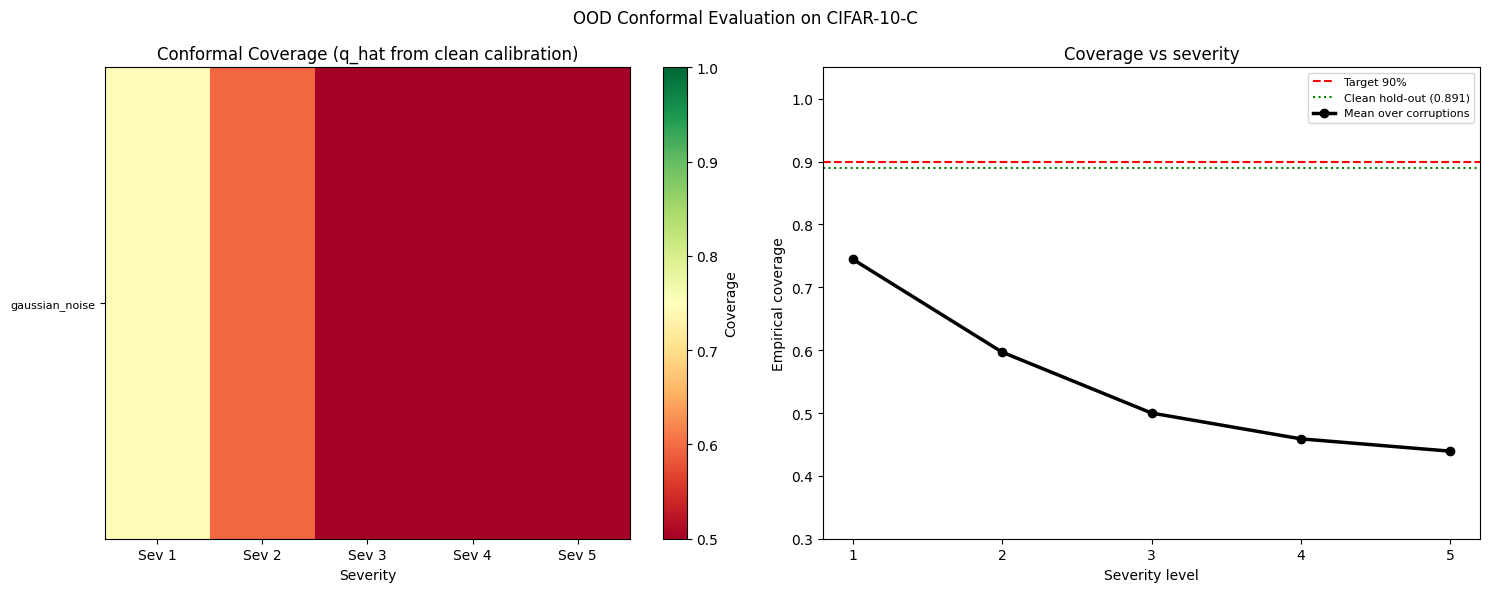

Saved: .\ood_conformal_coverage_merged.png


In [9]:
severities = [1, 2, 3, 4, 5]
cov_matrix = np.array([results[c] for c in CORRUPTIONS])

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

im = axes[0].imshow(cov_matrix, aspect='auto', vmin=0.5, vmax=1.0, cmap='RdYlGn',
                    extent=[0.5, 5.5, len(CORRUPTIONS) - 0.5, -0.5])
axes[0].set_xticks(severities)
axes[0].set_xticklabels([f'Sev {s}' for s in severities])
axes[0].set_yticks(range(len(CORRUPTIONS)))
axes[0].set_yticklabels(CORRUPTIONS, fontsize=8)
axes[0].set_xlabel('Severity')
axes[0].set_title('Conformal Coverage (q_hat from clean calibration)')
plt.colorbar(im, ax=axes[0], label='Coverage')

mean_cov_per_sev = cov_matrix.mean(axis=0)
axes[1].axhline(1 - ALPHA, color='red', linestyle='--', lw=1.5, label=f'Target {1-ALPHA:.0%}')
axes[1].axhline(cov_clean, color='green', linestyle=':', lw=1.5, label=f'Clean hold-out ({cov_clean:.3f})')
for c in CORRUPTIONS:
    axes[1].plot(severities, results[c], alpha=0.35, lw=1)
axes[1].plot(severities, mean_cov_per_sev, color='black', lw=2.5, marker='o', label='Mean over corruptions')
axes[1].set_xlabel('Severity level')
axes[1].set_ylabel('Empirical coverage')
axes[1].set_title('Coverage vs severity')
axes[1].set_ylim(0.3, 1.05)
axes[1].set_xticks(severities)
axes[1].legend(fontsize=8)

plt.suptitle('OOD Conformal Evaluation on CIFAR-10-C', fontsize=12)
plt.tight_layout()
ood_plot_path = os.path.join(OUTPUT_DIR, 'ood_conformal_coverage_merged.png')
plt.savefig(ood_plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {ood_plot_path}')

In [10]:
# Optional diagnostic: class-wise coverage for one corruption/severity pair
loader_spot = load_corrupted_loader(TARGET_CORRUPTION, TARGET_SEVERITY, DATA_C_DIR, mean, std, BATCH_SIZE)

class_covered = [0] * 10
class_total = [0] * 10
model.eval()
with torch.no_grad():
    for X_b, y_b in loader_spot:
        probs = torch.softmax(model(X_b.to(device)), dim=1).cpu()
        pred_sets = (1.0 - probs) <= q_hat
        for i, y_true in enumerate(y_b):
            c = y_true.item()
            class_covered[c] += int(pred_sets[i, c].item())
            class_total[c] += 1

print(f'Per-class coverage for {TARGET_CORRUPTION}, severity {TARGET_SEVERITY}')
for i, cls in enumerate(CLASSES):
    cov = class_covered[i] / max(class_total[i], 1)
    print(f'{cls:<12} {cov:.3f}')

Per-class coverage for gaussian_noise, severity 3
airplane     0.188
automobile   0.585
bird         0.394
cat          0.324
deer         0.741
dog          0.139
frog         0.989
horse        0.355
ship         0.547
truck        0.738


## 5) Drift detector definitions (PCA + MMD, KS, CUSUM)

In [13]:
%pip install scikit-learn

  Using cached scikit_learn-1.8.0-cp312-cp312-win_amd64.whl.metadata (11 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.8.0-cp312-cp312-win_amd64.whl (8.0 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)

   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- --------------------------

In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from scipy.stats import wasserstein_distance

In [15]:
class OnlinePCA:
    def __init__(self, n_components=32):
        self.n_components = n_components
        self.mean_ = None
        self.components_ = None

    def fit(self, X):
        X = X.float()
        self.mean_ = X.mean(0)
        Xc = X - self.mean_
        _, _, Vt = torch.linalg.svd(Xc, full_matrices=False)
        self.components_ = Vt[:self.n_components]
        return self

    def transform(self, X):
        return (X.float() - self.mean_) @ self.components_.T


def _median_sigma(X):
    if len(X) > 500:
        idx = torch.randperm(len(X))[:500]
        X = X[idx]
    dists = torch.cdist(X, X)
    return dists.median().item() + 1e-6


def _rbf_kernel(A, B, sigma):
    AA = (A ** 2).sum(1, keepdim=True)
    BB = (B ** 2).sum(1, keepdim=True)
    dist = AA + BB.T - 2 * A @ B.T
    return torch.exp(-dist / (2 * sigma ** 2))


def mmd_statistic(X_ref, X_new, sigma=None):
    if sigma is None:
        sigma = _median_sigma(torch.cat([X_ref, X_new]))
    n, m = len(X_ref), len(X_new)
    Krr = _rbf_kernel(X_ref, X_ref, sigma)
    Knn = _rbf_kernel(X_new, X_new, sigma)
    Krn = _rbf_kernel(X_ref, X_new, sigma)
    mmd2 = (
        (Krr.sum() - Krr.trace()) / (n * (n - 1))
        + (Knn.sum() - Knn.trace()) / (m * (m - 1))
        - 2 * Krn.mean()
    ).item()
    return mmd2, sigma


def permutation_mmd_threshold(X_ref, X_new, n_perm=300, alpha=0.05):
    combined = torch.cat([X_ref, X_new], dim=0)
    n = len(X_ref)
    sigma = _median_sigma(combined)
    obs_mmd, _ = mmd_statistic(X_ref, X_new, sigma)
    null_mmds = []
    for _ in range(n_perm):
        perm = torch.randperm(len(combined))
        val, _ = mmd_statistic(combined[perm[:n]], combined[perm[n:]], sigma)
        null_mmds.append(val)
    threshold = float(np.quantile(null_mmds, 1 - alpha))
    print(f'MMD observed={obs_mmd:.6f} null_{1-alpha:.2f}={threshold:.6f} sigma={sigma:.3f}')
    return threshold, sigma


def ks_confidence_drift(ref_confs, new_confs, alpha=0.05):
    stat, p = ks_2samp(ref_confs, new_confs)
    return stat, p, bool(p < alpha)


class CUSUMDetector:
    def __init__(self, mu0, sigma, delta=1.0, h_mult=5.0):
        self.k = delta * sigma / 2
        self.h = h_mult * sigma
        self.mu0 = mu0
        self.S = 0.0
        self._step = 0
        self.alerts = []

    def update(self, value):
        self.S = max(0.0, self.S + (value - self.mu0) - self.k)
        self._step += 1
        if self.S > self.h:
            self.alerts.append(self._step)
            self.S = 0.0
            return True
        return False


class PageHinkleyDetector:
    """Page-Hinkley test for mean increase in a streaming statistic."""
    def __init__(self, delta=0.01, threshold=0.5):
        self.delta = delta
        self.threshold = threshold
        self.t = 0
        self.mean = 0.0
        self.cum_sum = 0.0
        self.min_cum_sum = 0.0
        self.ph_value = 0.0

    def update(self, value):
        self.t += 1
        self.mean += (value - self.mean) / self.t
        self.cum_sum += value - self.mean - self.delta
        self.min_cum_sum = min(self.min_cum_sum, self.cum_sum)
        self.ph_value = self.cum_sum - self.min_cum_sum
        if self.ph_value > self.threshold:
            self.cum_sum = 0.0
            self.min_cum_sum = 0.0
            self.ph_value = 0.0
            return True
        return False


def population_stability_index(ref_vals, new_vals, bins=10, eps=1e-8):
    """PSI between two 1D distributions using quantile bins from reference values."""
    ref_vals = np.asarray(ref_vals)
    new_vals = np.asarray(new_vals)
    edges = np.quantile(ref_vals, np.linspace(0, 1, bins + 1))
    edges = np.unique(edges)
    if len(edges) < 3:
        return 0.0
    ref_hist, _ = np.histogram(ref_vals, bins=edges)
    new_hist, _ = np.histogram(new_vals, bins=edges)
    ref_prop = ref_hist / max(ref_hist.sum(), 1)
    new_prop = new_hist / max(new_hist.sum(), 1)
    ref_prop = np.clip(ref_prop, eps, 1.0)
    new_prop = np.clip(new_prop, eps, 1.0)
    return float(np.sum((new_prop - ref_prop) * np.log(new_prop / ref_prop)))


def js_label_shift(ref_probs, new_probs, eps=1e-12):
    """Jensen-Shannon divergence of mean predicted class distributions."""
    ref_dist = np.clip(np.asarray(ref_probs).mean(axis=0), eps, 1.0)
    new_dist = np.clip(np.asarray(new_probs).mean(axis=0), eps, 1.0)
    ref_dist = ref_dist / ref_dist.sum()
    new_dist = new_dist / new_dist.sum()
    return float(jensenshannon(ref_dist, new_dist, base=2.0) ** 2)

class AdaptiveMMDDetector:
    def __init__(self, initial_ref, n_perm=300, alpha=0.05):
        self.ref_window = initial_ref.clone()
        self.n_perm = n_perm
        self.alpha = alpha
        self._calibrate()

    def _calibrate(self):
        # Calibrate threshold using the first and second halves of the current reference window
        half = len(self.ref_window) // 2
        self.threshold, self.sigma = permutation_mmd_threshold(
            self.ref_window[:half], self.ref_window[half:], 
            n_perm=self.n_perm, alpha=self.alpha
        )

    def update_and_test(self, new_window):
        # Subsample reference to match new window size for balanced MMD
        idx = torch.randperm(len(self.ref_window))[:len(new_window)]
        obs_mmd, _ = mmd_statistic(self.ref_window[idx], new_window, sigma=self.sigma)
        
        drift_detected = obs_mmd > self.threshold
        
        if drift_detected:
            # ADAPT: Replace reference with the new distribution and recalibrate
            self.ref_window = new_window.clone()
            self._calibrate()
            
        return obs_mmd, drift_detected

def c2st_drift(ref_emb, new_emb, cv=5, threshold_auc=0.60):
    """Classifier Two-Sample Test using a lightweight Random Forest."""
    X_ref = ref_emb.cpu().numpy()
    X_new = new_emb.cpu().numpy()
    
    # Subsample reference to match the new window size to prevent class imbalance
    idx = np.random.choice(len(X_ref), size=len(X_new), replace=False)
    X_ref_sub = X_ref[idx]
    
    X = np.vstack((X_ref_sub, X_new))
    y = np.hstack((np.zeros(len(X_ref_sub)), np.ones(len(X_new))))
    
    clf = RandomForestClassifier(max_depth=3, n_estimators=50, n_jobs=-1, random_state=42)
    scores = cross_val_score(clf, X, y, cv=cv, scoring='roc_auc')
    
    mean_auc = np.mean(scores)
    return mean_auc, bool(mean_auc > threshold_auc)

def wasserstein_confidence_drift(ref_confs, new_confs, threshold=0.05):
    """Earth Mover's Distance on confidence distributions."""
    w_dist = wasserstein_distance(ref_confs, new_confs)
    return w_dist, bool(w_dist > threshold)


@torch.no_grad()
def get_embeddings(model, loader, device, max_batches=None):
    model.eval()
    embs = []
    for i, (X_b, _) in enumerate(loader):
        if max_batches is not None and i >= max_batches:
            break
        embs.append(model.get_embeddings(X_b.to(device)).cpu())
    return torch.cat(embs)


## 6) Drift detector calibration on clean calibration data

In [16]:
from river import tree as river_tree
from river import drift as river_drift

In [18]:

ref_emb_raw = get_embeddings(model, cal_loader_clean, device)
pca = OnlinePCA(n_components=32).fit(ref_emb_raw)
ref_emb = pca.transform(ref_emb_raw)
 
ref_confs = []
ref_probs_all = []
model.eval()
with torch.no_grad():
    for X_b, _ in cal_loader_clean:
        probs = torch.softmax(model(X_b.to(device)), dim=1).cpu()
        ref_probs_all.append(probs.numpy())
        ref_confs.extend(probs.max(dim=1).values.tolist())
ref_confs = np.array(ref_confs)
ref_probs_all = np.concatenate(ref_probs_all, axis=0)
 
half = len(ref_emb) // 2
mmd_threshold, mmd_sigma = permutation_mmd_threshold(
    ref_emb[:half], ref_emb[half:], n_perm=MMD_PERMUTATIONS, alpha=0.05
)
 
# Baseline for CUSUM: conformal set-size behavior on clean calibration data
ref_set_sizes = []
with torch.no_grad():
    for X_b, _ in cal_loader_clean:
        probs = torch.softmax(model(X_b.to(device)), dim=1).cpu()
        sizes = ((1.0 - probs) <= q_hat).sum(dim=1).float().tolist()
        ref_set_sizes.extend(sizes)
 
mu0 = float(np.mean(ref_set_sizes))
sigma = float(np.std(ref_set_sizes)) + 1e-6

adwin = drift.ADWIN()
cusum = CUSUMDetector(mu0=mu0, sigma=sigma, delta=1.0, h_mult=5.0)
page_hinkley = PageHinkleyDetector(delta=0.1 * sigma, threshold=3.0 * sigma)
 
# Null thresholds for PSI and JS divergence under no-drift (clean vs. clean random windows)
window_n = STREAM_WINDOW * BATCH_SIZE
rng = np.random.default_rng(SEED)
psi_null = []
js_null = []
for _ in range(NULL_SAMPLES):
    idx_a = rng.choice(len(ref_confs), size=min(window_n, len(ref_confs)), replace=False)
    idx_b = rng.choice(len(ref_confs), size=min(window_n, len(ref_confs)), replace=False)
    psi_null.append(population_stability_index(ref_confs[idx_a], ref_confs[idx_b]))
 
    jdx_a = rng.choice(len(ref_probs_all), size=min(window_n, len(ref_probs_all)), replace=False)
    jdx_b = rng.choice(len(ref_probs_all), size=min(window_n, len(ref_probs_all)), replace=False)
    js_null.append(js_label_shift(ref_probs_all[jdx_a], ref_probs_all[jdx_b]))
 
psi_threshold = float(np.quantile(psi_null, 0.95))
js_threshold = float(np.quantile(js_null, 0.95))
adaptive_mmd = AdaptiveMMDDetector(initial_ref=ref_emb, n_perm=MMD_PERMUTATIONS, alpha=0.05)

# 2. Initialize River's DDM for tracking Conformal Coverage Errors
ddm_detector = river_drift.binary.DDM()

# 3. Calculate null threshold for Wasserstein distance (clean vs clean)
w_dist_null = []
for _ in range(NULL_SAMPLES):
    idx_a = rng.choice(len(ref_confs), size=min(window_n, len(ref_confs)), replace=False)
    idx_b = rng.choice(len(ref_confs), size=min(window_n, len(ref_confs)), replace=False)
    w_dist_null.append(wasserstein_distance(ref_confs[idx_a], ref_confs[idx_b]))
w_dist_threshold = float(np.quantile(w_dist_null, 0.95))

print(f'Wasserstein thresh: {w_dist_threshold:.6f}')
print(f'Ref conf mean/std: {ref_confs.mean():.3f} / {ref_confs.std():.3f}')
print(f'MMD threshold    : {mmd_threshold:.6f} (sigma={mmd_sigma:.3f})')
print(f'CUSUM mu0/sigma  : {mu0:.3f} / {sigma:.3f}')
print(f'Page-Hinkley     : delta={page_hinkley.delta:.4f} threshold={page_hinkley.threshold:.4f}')
print(f'PSI threshold    : {psi_threshold:.6f}')
print(f'JS threshold     : {js_threshold:.6f}')
 

MMD observed=0.000017 null_0.95=0.000254 sigma=20.669
MMD observed=0.000017 null_0.95=0.000240 sigma=20.333
Wasserstein thresh: 0.022788
Ref conf mean/std: 0.782 / 0.212
MMD threshold    : 0.000254 (sigma=20.669)
CUSUM mu0/sigma  : 1.397 / 0.594
Page-Hinkley     : delta=0.0594 threshold=1.7823
PSI threshold    : 0.045163
JS threshold     : 0.005812


## 7) Stream simulation: clean -> corrupted

In [21]:
clean_stream_loader = DataLoader(clean_test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
noisy_stream_loader = load_corrupted_loader(TARGET_CORRUPTION, TARGET_SEVERITY, DATA_C_DIR, mean, std, BATCH_SIZE)
 
stream_batches = []
for i, batch in enumerate(clean_stream_loader):
    if i >= STREAM_CLEAN_BATCHES:
        break
    stream_batches.append(('CLEAN', batch))
 
for i, batch in enumerate(noisy_stream_loader):
    if i >= STREAM_NOISY_BATCHES:
        break
    stream_batches.append((f'NOISY:{TARGET_CORRUPTION}:s{TARGET_SEVERITY}', batch))
 
window_emb_list = []
window_conf_batch_list = []
window_prob_batch_list = []
log = []
 
# Updated header to include the new detectors
print(f"{'Step':>4}  {'Source':>24}  {'SetSz':>6}  {'CUSUM':>7}  {'PH':>7}  {'MMD':>9}  {'KS-p':>7}  {'PSI':>8}  {'JS':>8}  {'Ad-MMD':>9}  {'C2ST':>6}  {'W-Dist':>7}  {'DDM':>4}  {'CVErr':>6}  Alerts")
print('-' * 170)
 
model.eval()
with torch.no_grad():
    for step, (source, (X_b, y_b)) in enumerate(stream_batches):
        X_b = X_b.to(device)
        y_b = y_b.to(device)
        
        probs = torch.softmax(model(X_b), dim=1).cpu()
        emb_raw = model.get_embeddings(X_b).cpu()
        emb = pca.transform(emb_raw)
 
        pred_sets = (1.0 - probs) <= q_hat
        avg_size = pred_sets.sum(dim=1).float().mean().item()
 
        window_emb_list.append(emb)
        window_conf_batch_list.append(probs.max(dim=1).values.numpy())
        window_prob_batch_list.append(probs.numpy())
 
        alerts = []
        mmd_val = float('nan')
        ks_p = float('nan')
        psi_val = float('nan')
        js_val = float('nan')
        
        # New detector values
        ad_mmd_val = float('nan')
        c2st_auc = float('nan')
        w_dist_val = float('nan')
 
        # ---- 1. DDM (Conformal Error Tracking) ----
        for i, y_true in enumerate(y_b):
            c = y_true.item()
            is_error = 0 if pred_sets[i, c].item() else 1
            ddm_detector.update(is_error)
            if ddm_detector.drift_detected and 'DDM' not in alerts:
                alerts.append('DDM')

        # ---- 2. Tracking Set Size Drifts ----
        if cusum.update(avg_size):
            alerts.append('CUSUM')
        if page_hinkley.update(avg_size):
            alerts.append('PH')
            adwin.update(avg_size)
        if adwin.drift_detected:  
            alerts.append('ADWIN')
 
        # ---- 3. Window-Based Distribution Detectors ----
        if len(window_emb_list) >= STREAM_WINDOW:
            new_emb = torch.cat(window_emb_list[-STREAM_WINDOW:])
            new_conf = np.concatenate(window_conf_batch_list[-STREAM_WINDOW:])
            new_prob = np.concatenate(window_prob_batch_list[-STREAM_WINDOW:], axis=0)
 
            # Existing: Static MMD
            idx = torch.randperm(len(ref_emb))[:len(new_emb)]
            mmd_val, _ = mmd_statistic(ref_emb[idx], new_emb, sigma=mmd_sigma)
            if mmd_val > mmd_threshold:
                alerts.append('MMD')
 
            # Existing: KS, PSI, JS
            _, ks_p, ks_drift = ks_confidence_drift(ref_confs, new_conf)
            if ks_drift:
                alerts.append('KS')
 
            psi_val = population_stability_index(ref_confs, new_conf)
            if psi_val > psi_threshold:
                alerts.append('PSI')
 
            js_val = js_label_shift(ref_probs_all, new_prob)
            if js_val > js_threshold:
                alerts.append('JS')

            # NEW: Adaptive MMD
            ad_mmd_val, ad_mmd_drift = adaptive_mmd.update_and_test(new_emb)
            if ad_mmd_drift:
                alerts.append('Ad-MMD')
                
            # NEW: Classifier Two-Sample Test (C2ST)
            c2st_auc, c2st_drift_detected = c2st_drift(ref_emb, new_emb)
            if c2st_drift_detected:
                alerts.append('C2ST')
                
            # NEW: Wasserstein Distance
            w_dist_val, w_drift = wasserstein_confidence_drift(ref_confs, new_conf, threshold=w_dist_threshold)
            if w_drift:
                alerts.append('W-Dist')
 
        # Formatting for console output
        alert_str   = ','.join(alerts) if alerts else '-'
        mmd_str     = f'{mmd_val:9.5f}' if not np.isnan(mmd_val) else '      nan'
        ks_str      = f'{ks_p:7.3f}'    if not np.isnan(ks_p)    else '    nan'
        psi_str     = f'{psi_val:8.5f}' if not np.isnan(psi_val) else '     nan'
        js_str      = f'{js_val:8.5f}'  if not np.isnan(js_val)  else '     nan'
        ad_mmd_str  = f'{ad_mmd_val:9.5f}' if not np.isnan(ad_mmd_val) else '      nan'
        c2st_str    = f'{c2st_auc:6.3f}' if not np.isnan(c2st_auc)   else '   nan'
        w_dist_str  = f'{w_dist_val:7.4f}' if not np.isnan(w_dist_val) else '    nan'
        ddm_str     = '*' if 'DDM' in alerts else '-'
        
        # Assuming cvfdt_batch_err is calculated somewhere else in your broader scope as before
        print(f'{step:4d}  {source:>24}  {avg_size:6.2f}  {cusum.S:7.3f}  {page_hinkley.ph_value:7.3f}  {mmd_str}  {ks_str}  {psi_str}  {js_str}  {ad_mmd_str}  {c2st_str}  {w_dist_str}  {ddm_str:>4}  {alert_str}')
 
        log.append({
            'step':       step,
            'source':     source,
            'avg_size':   avg_size,
            'cusum_S':    cusum.S,
            'ph_value':   page_hinkley.ph_value,
            'mmd':        mmd_val,
            'ks_p':       ks_p,
            'psi':        psi_val,
            'js':         js_val,
            'ad_mmd':     ad_mmd_val,         # NEW
            'c2st_auc':   c2st_auc,           # NEW
            'w_dist':     w_dist_val,         # NEW
            'alert':      bool(alerts),
            'alerts':     alerts,
        })

Step                    Source   SetSz    CUSUM       PH        MMD     KS-p       PSI        JS     Ad-MMD    C2ST   W-Dist   DDM   CVErr  Alerts
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------
   0                     CLEAN    1.37    0.000    0.000        nan      nan       nan       nan        nan     nan      nan     -  -
   1                     CLEAN    1.40    0.000    0.000        nan      nan       nan       nan        nan     nan      nan     -  -
   2                     CLEAN    1.34    0.000    0.000        nan      nan       nan       nan        nan     nan      nan     -  -
   3                     CLEAN    1.47    0.000    0.025        nan      nan       nan       nan        nan     nan      nan     -  -
   4                     CLEAN    1.37    0.000    0.000   -0.00009    0.909   0.00616   0.00332   -0.00000   0.463   0.0053     -  -
   5        

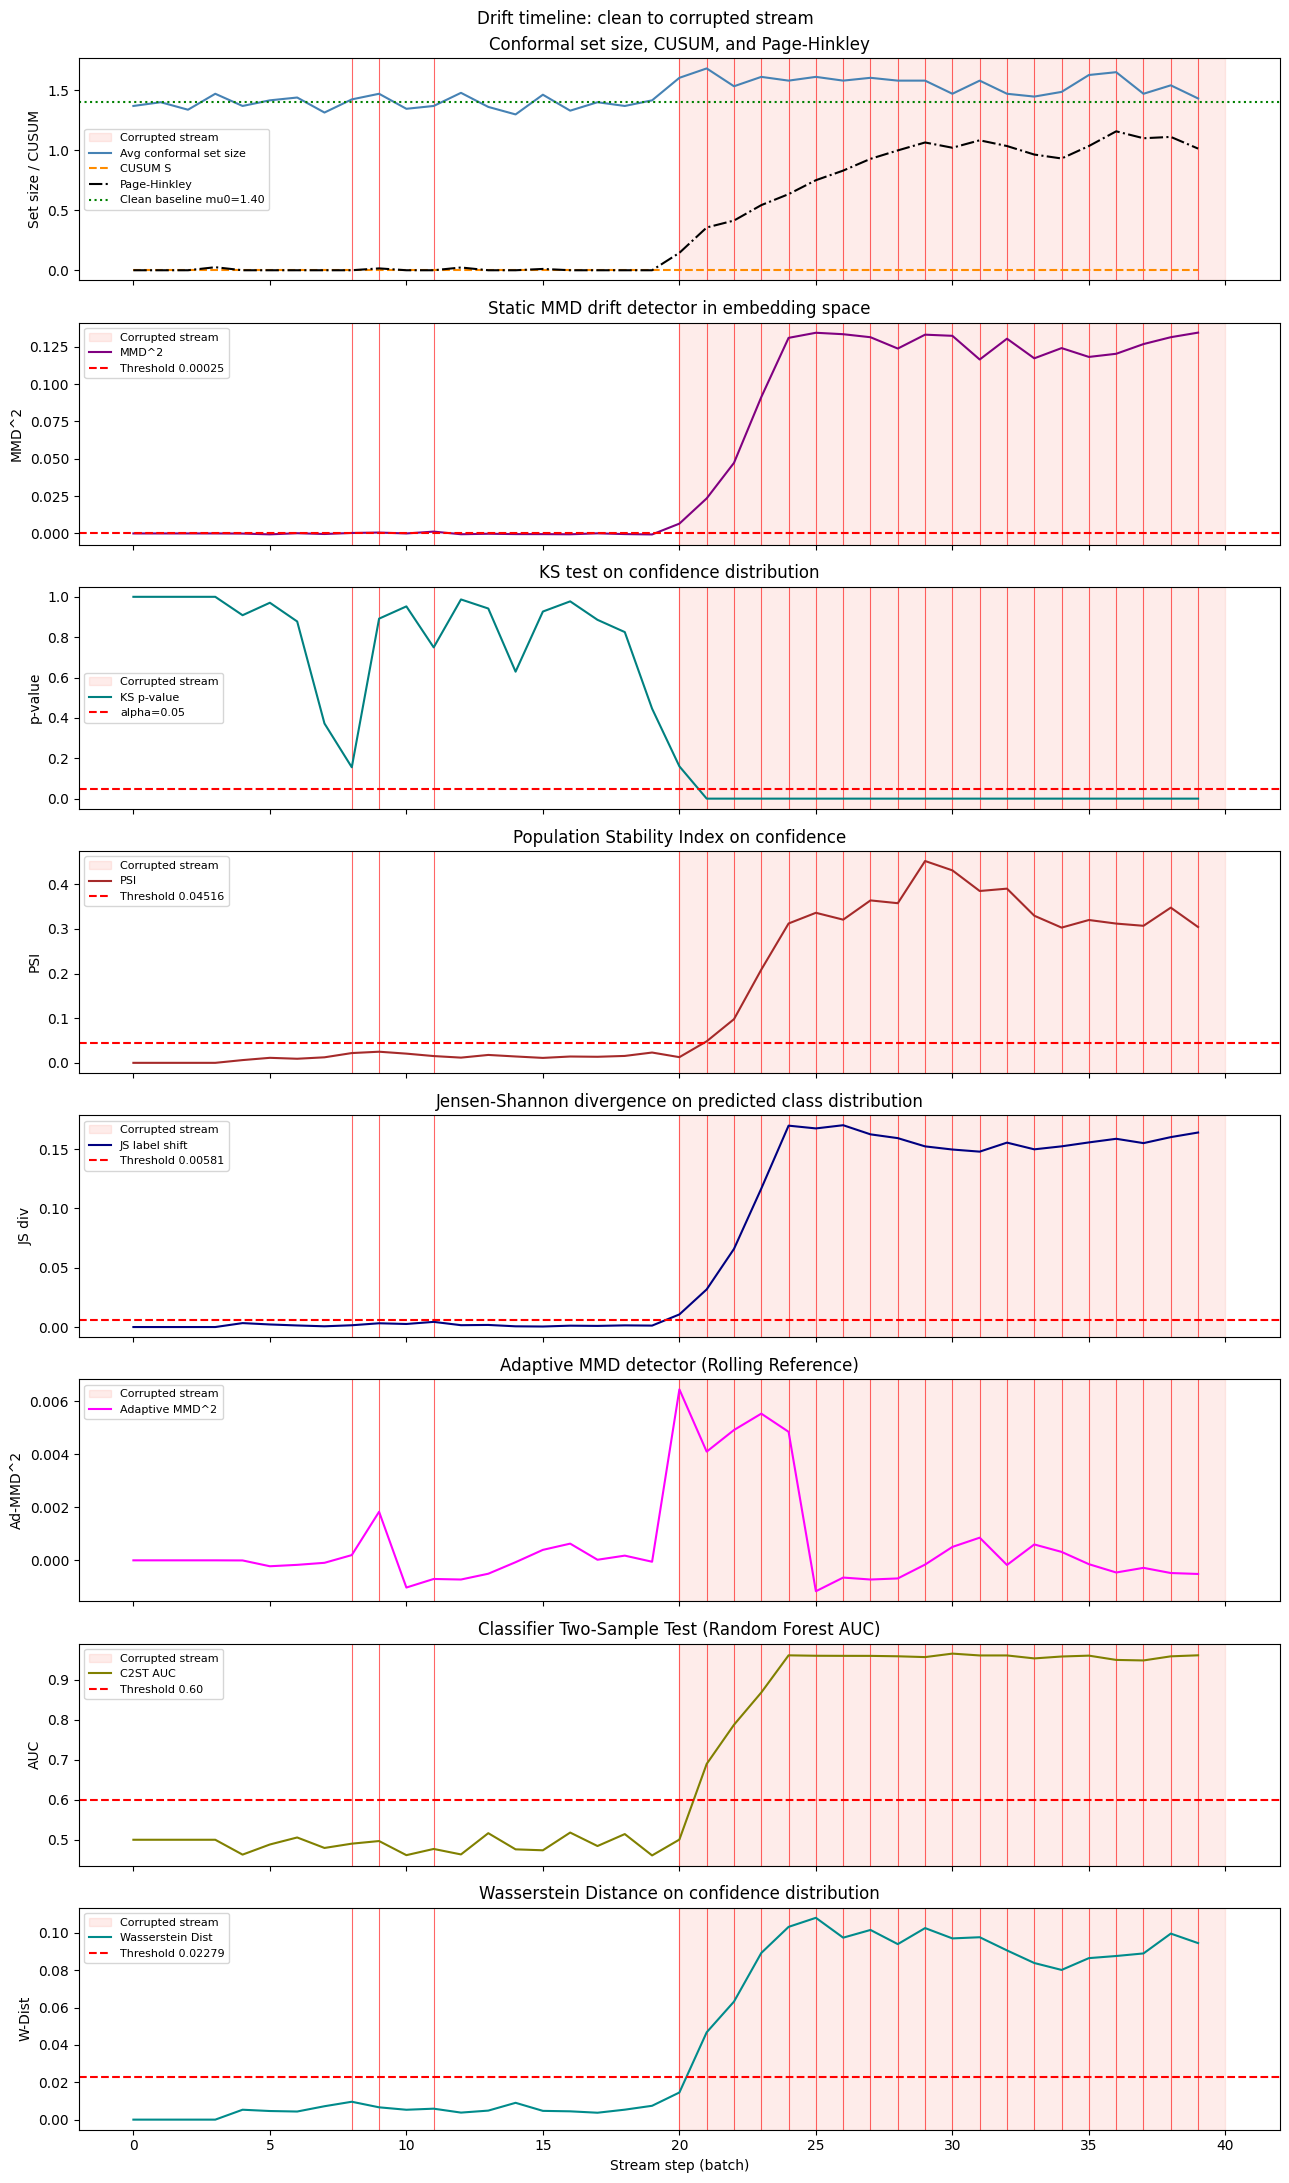

Saved: .\drift_timeline_merged.png
Total alert steps: 23 -> [8, 9, 11, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39]


In [22]:
steps = [r['step'] for r in log]
set_sizes = [r['avg_size'] for r in log]
cusum_vals = [r['cusum_S'] for r in log]
ph_vals = [r['ph_value'] for r in log]
mmd_vals = [r['mmd'] if not np.isnan(r['mmd']) else 0.0 for r in log]
ks_ps = [r['ks_p'] if not np.isnan(r['ks_p']) else 1.0 for r in log]
psi_vals = [r['psi'] if not np.isnan(r['psi']) else 0.0 for r in log]
js_vals = [r['js'] if not np.isnan(r['js']) else 0.0 for r in log]

# Extract new metrics
ad_mmd_vals = [r['ad_mmd'] if not np.isnan(r['ad_mmd']) else 0.0 for r in log]
c2st_aucs = [r['c2st_auc'] if not np.isnan(r['c2st_auc']) else 0.5 for r in log] # Base AUC is 0.5
w_dist_vals = [r['w_dist'] if not np.isnan(r['w_dist']) else 0.0 for r in log]

alerts = [r['step'] for r in log if r['alert']]

transition = STREAM_CLEAN_BATCHES

# Increased subplots from 5 to 8, adjusted figure height
fig, axes = plt.subplots(8, 1, figsize=(13, 22), sharex=True)
for ax in axes:
    ax.axvspan(transition, max(steps) + 1, color='salmon', alpha=0.15, label='Corrupted stream')
    for a in alerts:
        ax.axvline(a, color='red', linewidth=0.8, alpha=0.6)

axes[0].plot(steps, set_sizes, color='steelblue', label='Avg conformal set size')
axes[0].plot(steps, cusum_vals, color='darkorange', linestyle='--', label='CUSUM S')
axes[0].plot(steps, ph_vals, color='black', linestyle='-.', label='Page-Hinkley')
axes[0].axhline(mu0, color='green', linestyle=':', label=f'Clean baseline mu0={mu0:.2f}')
axes[0].set_ylabel('Set size / CUSUM')
axes[0].set_title('Conformal set size, CUSUM, and Page-Hinkley')
axes[0].legend(fontsize=8)

axes[1].plot(steps, mmd_vals, color='purple', label='MMD^2')
axes[1].axhline(mmd_threshold, color='red', linestyle='--', label=f'Threshold {mmd_threshold:.5f}')
axes[1].set_ylabel('MMD^2')
axes[1].set_title('Static MMD drift detector in embedding space')
axes[1].legend(fontsize=8)

axes[2].plot(steps, ks_ps, color='teal', label='KS p-value')
axes[2].axhline(0.05, color='red', linestyle='--', label='alpha=0.05')
axes[2].set_ylabel('p-value')
axes[2].set_title('KS test on confidence distribution')
axes[2].legend(fontsize=8)

axes[3].plot(steps, psi_vals, color='brown', label='PSI')
axes[3].axhline(psi_threshold, color='red', linestyle='--', label=f'Threshold {psi_threshold:.5f}')
axes[3].set_ylabel('PSI')
axes[3].set_title('Population Stability Index on confidence')
axes[3].legend(fontsize=8)

axes[4].plot(steps, js_vals, color='navy', label='JS label shift')
axes[4].axhline(js_threshold, color='red', linestyle='--', label=f'Threshold {js_threshold:.5f}')
axes[4].set_ylabel('JS div')
axes[4].set_title('Jensen-Shannon divergence on predicted class distribution')
axes[4].legend(fontsize=8)

# --- NEW PLOTS BELOW ---

axes[5].plot(steps, ad_mmd_vals, color='magenta', label='Adaptive MMD^2')
axes[5].set_ylabel('Ad-MMD^2')
axes[5].set_title('Adaptive MMD detector (Rolling Reference)')
axes[5].legend(fontsize=8)

axes[6].plot(steps, c2st_aucs, color='olive', label='C2ST AUC')
axes[6].axhline(0.60, color='red', linestyle='--', label='Threshold 0.60')
axes[6].set_ylabel('AUC')
axes[6].set_title('Classifier Two-Sample Test (Random Forest AUC)')
axes[6].legend(fontsize=8)

axes[7].plot(steps, w_dist_vals, color='darkcyan', label='Wasserstein Dist')
axes[7].axhline(w_dist_threshold, color='red', linestyle='--', label=f'Threshold {w_dist_threshold:.5f}')
axes[7].set_ylabel('W-Dist')
axes[7].set_xlabel('Stream step (batch)')
axes[7].set_title('Wasserstein Distance on confidence distribution')
axes[7].legend(fontsize=8)

plt.suptitle('Drift timeline: clean to corrupted stream', y=0.99)
plt.tight_layout()
drift_plot_path = os.path.join(OUTPUT_DIR, 'drift_timeline_merged.png')
plt.savefig(drift_plot_path, dpi=140, bbox_inches='tight')
plt.show()

print(f'Saved: {drift_plot_path}')
print(f'Total alert steps: {len(alerts)} -> {alerts}')

## 8) Final summary

In [23]:
avg_by_corr = {c: float(np.mean(v)) for c, v in results.items()}
best_corr = max(avg_by_corr, key=avg_by_corr.get)
worst_corr = min(avg_by_corr, key=avg_by_corr.get)
overall_mean = float(np.mean(list(avg_by_corr.values())))

# Tally up all alerts from the log
detector_counts = {}
for row in log:
    for tag in row['alerts']:
        detector_counts[tag] = detector_counts.get(tag, 0) + 1

# Sort detector counts by most active
sorted_detectors = dict(sorted(detector_counts.items(), key=lambda item: item[1], reverse=True))

print('=' * 85)
print('FINAL SUMMARY & METRICS')
print('=' * 85)
print(f'Model                : SimpleCNN (trained on clean CIFAR-10 train)')
print(f'Conformal alpha      : {ALPHA}')
print(f'Conformal q_hat      : {q_hat:.4f}')
print(f'Clean hold-out cov   : {cov_clean:.4f} (target >= {1-ALPHA:.2f})')
print(f'Best corruption mean : {best_corr} ({avg_by_corr[best_corr]:.4f})')
print(f'Worst corruption mean: {worst_corr} ({avg_by_corr[worst_corr]:.4f})')
print(f'Overall OOD mean cov : {overall_mean:.4f}')
print('-' * 85)
print(f'Drift target stream  : {TARGET_CORRUPTION}, severity {TARGET_SEVERITY}')
print(f'Total Drift alerts   : {len(alerts)} at steps {alerts}')
print(f'Alerts by detector   : {sorted_detectors}')
print('=' * 85)
print('Takeaway: Conformal validity is strictly anchored to the calibration distribution.')
print('OOD corruption drastically reduces empirical coverage. The integrated drift detectors')
print('(Static/Adaptive MMD, C2ST, W-Dist, DDM, etc.) provide a robust, multi-faceted defense')
print('to flag embedding shifts, coverage drops, and confidence changes online.')

FINAL SUMMARY & METRICS
Model                : SimpleCNN (trained on clean CIFAR-10 train)
Conformal alpha      : 0.1
Conformal q_hat      : 0.8279
Clean hold-out cov   : 0.8906 (target >= 0.90)
Best corruption mean : gaussian_noise (0.5479)
Worst corruption mean: gaussian_noise (0.5479)
Overall OOD mean cov : 0.5479
-------------------------------------------------------------------------------------
Drift target stream  : gaussian_noise, severity 3
Total Drift alerts   : 23 at steps [8, 9, 11, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39]
Alerts by detector   : {'MMD': 23, 'JS': 20, 'KS': 19, 'PSI': 19, 'C2ST': 19, 'W-Dist': 19, 'Ad-MMD': 6, 'DDM': 1}
Takeaway: Conformal validity is strictly anchored to the calibration distribution.
OOD corruption drastically reduces empirical coverage. The integrated drift detectors
(Static/Adaptive MMD, C2ST, W-Dist, DDM, etc.) provide a robust, multi-faceted defense
to flag embedding shifts, coverage drops, and co